## Data from World Happiness Report

The World Happiness Report is an annual publication of the United Nations Sustainable Development Solutions Network. It contains articles, and rankings of national happiness based on respondent ratings of their own lives, which the report also correlates with various life factors.

In this notebook we will explore the happiness of different countries and the features associated.
The datasets that we will use are available in *Data*: **happiness2020.pkl** and **countries_info.csv**.

Although the features are self-explanatory, here a summary: 

**happiness2020.pkl**
* country: *Name of the country*
* happiness_score: *Happiness score*
* social_support: *Social support (mitigation the effects of inequality)*
* healthy_life_expectancy: *Healthy Life Expectancy*
* freedom_of_choices: *Freedom to make life choices*
* generosity: *Generosity (charity, volunteers)*
* perception_of_corruption: *Corruption Perception*
* world_region: *Area of the world of the country*

**countries_info.csv**
* country_name: *Name of the country*
* area: *Area in sq mi*
* population: *Number of people*
* literacy: *Literacy percentage*

In [1]:
!head Data/countries_info.csv

country_name,area,population,literacy
afghanistan,647500,31056997,"36,0"
albania,28748,3581655,"86,5"
algeria,2381740,32930091,"70,0"
argentina,2766890,39921833,"97,1"
armenia,29800,2976372,"98,6"
australia,7686850,20264082,"100,0"
austria,83870,8192880,"98,0"
azerbaijan,86600,7961619,"97,0"
bahrain,665,698585,"89,1"


In [2]:
!head Data/happiness2020.csv

country,happiness_score,social_support,healthy_life_expectancy,freedom_of_choices,generosity,perception_of_corruption,world_region
Afghanistan,2.566900015,0.470366955,52.59000015,0.39657300700000003,-0.0964294,0.9336865540000001,South Asia
Albania,4.882699966000001,0.671070457,68.70813751,0.7819942240000001,-0.042309489000000006,0.896303713,Central and Eastern Europe
Algeria,5.005099773,0.8033851390000001,65.90517426,0.46661090899999996,-0.121105164,0.7354851370000001,Middle East and North Africa
Argentina,5.974699974,0.900567949,68.80380249,0.831132412,-0.194913864,0.8420098420000001,Latin America and Caribbean
Armenia,4.676799774,0.7574794290000001,66.75065613,0.7120178340000001,-0.13877961,0.7735447879999999,Commonwealth of Independent States
Australia,7.222799778,0.9448546170000001,73.60453796,0.915431738,0.19046016,0.41516912,North America and ANZ
Austria,7.294199944,0.9280458690000001,73.00250244,0.899989486,0.085429221,0.49995487899999996,Western Europe
Azerbaijan,5.164800167,0.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

DATA_FOLDER = 'Data/'

HAPPINESS_DATASET = DATA_FOLDER+"happiness2020.csv"
COUNTRIES_DATASET = DATA_FOLDER+"countries_info.csv"

## Task 1: Load the data

Load the 2 datasets in Pandas dataframes (called *happiness* and *countries*), and show the first rows.


**Hint**: Use the correct reader and verify the data has the expected format.

In [4]:
# Write your code here
df1 = pd.read_csv(COUNTRIES_DATASET,sep=",",header=0,index_col="country_name",converters={"country_name" : str.title})
df1.head(1)

,area,population,literacy
country_name,,,
Afghanistan,647500,31056997,"36,0"


In [5]:
df2 = pd.read_csv(HAPPINESS_DATASET,sep=",",header=0,index_col = "country")
df2.head(1)

,happiness_score,social_support,healthy_life_expectancy,freedom_of_choices,generosity,perception_of_corruption,world_region
country,,,,,,,
Afghanistan,2.5669,0.470367,52.59,0.396573,-0.096429,0.933687,South Asia


## Task 2: Let's merge the data

Create a dataframe called *country_features* by merging *happiness* and *countries*. A row of this dataframe must describe all the features that we have about a country.

**Hint**: Verify that all the rows are in the final dataframe.

In [6]:
# Write your code here
df = df1.join(df2,how="inner")
df.head()


,area,population,literacy,happiness_score,social_support,healthy_life_expectancy,freedom_of_choices,generosity,perception_of_corruption,world_region
country_name,,,,,,,,,,
Afghanistan,647500,31056997,"36,0",2.5669,0.470367,52.590000,0.396573,-0.096429,0.933687,South Asia
Albania,28748,3581655,"86,5",4.8827,0.671070,68.708138,0.781994,-0.042309,0.896304,Central and Eastern Europe
Algeria,2381740,32930091,"70,0",5.0051,0.803385,65.905174,0.466611,-0.121105,0.735485,Middle East and North Africa
Argentina,2766890,39921833,"97,1",5.9747,0.900568,68.803802,0.831132,-0.194914,0.842010,Latin America and Caribbean
Armenia,29800,2976372,"98,6",4.6768,0.757479,66.750656,0.712018,-0.138780,0.773545,Commonwealth of Independent States


## Task 3: Where are people happier?

Print the top 10 countries based on their happiness score (higher is better).

In [7]:
# Write your code here
df = df.sort_values(by="happiness_score",ascending=False)
df.head(10)

,area,population,literacy,happiness_score,social_support,healthy_life_expectancy,freedom_of_choices,generosity,perception_of_corruption,world_region
country_name,,,,,,,,,,
Finland,338145,5231372,"100,0",7.8087,0.954330,71.900825,0.949172,-0.059482,0.195445,Western Europe
Denmark,43094,5450661,"100,0",7.6456,0.955991,72.402504,0.951444,0.066202,0.168489,Western Europe
Switzerland,41290,7523934,"99,0",7.5599,0.942847,74.102448,0.921337,0.105911,0.303728,Western Europe
Iceland,103000,299388,"99,9",7.5045,0.974670,73.000000,0.948892,0.246944,0.711710,Western Europe
Norway,323802,4610820,"100,0",7.4880,0.952487,73.200783,0.955750,0.134533,0.263218,Western Europe
Netherlands,41526,16491461,"99,0",7.4489,0.939139,72.300919,0.908548,0.207612,0.364717,Western Europe
Sweden,449964,9016596,"99,0",7.3535,0.926311,72.600769,0.939144,0.111615,0.250880,Western Europe
New Zealand,268680,4076140,"99,0",7.2996,0.949119,73.202629,0.936217,0.191598,0.221139,North America and ANZ
Austria,83870,8192880,"98,0",7.2942,0.928046,73.002502,0.899989,0.085429,0.499955,Western Europe


We are interested to know in what world region people are happier. 

Create and print a dataframe with the (1) average happiness score and (2) the number of contries for each world region.
Sort the result to show the happiness ranking.

In [8]:
# Write your code here
grouped = df.groupby("world_region")
count = grouped.size()
print(count)

world_region
Central and Eastern Europe            14
Commonwealth of Independent States    12
East Asia                              3
Latin America and Caribbean           20
Middle East and North Africa          16
North America and ANZ                  4
South Asia                             6
Southeast Asia                         8
Sub-Saharan Africa                    32
Western Europe                        20
dtype: int64


In [9]:
avg_happiness = grouped["happiness_score"].mean()
print(avg_happiness)

world_region
Central and Eastern Europe            5.891393
Commonwealth of Independent States    5.358342
East Asia                             5.483633
Latin America and Caribbean           5.971280
Middle East and North Africa          5.269306
North America and ANZ                 7.173525
South Asia                            4.355083
Southeast Asia                        5.517788
Sub-Saharan Africa                    4.393856
Western Europe                        6.967405
Name: happiness_score, dtype: float64


The first region has only a few countries! What are them and what is their score?

In [10]:
df_small_happy = df.loc[df["world_region"] == "North America and ANZ",["happiness_score"]]
df_small_happy.head()

,happiness_score
country_name,
New Zealand,7.2996
Canada,7.2321
Australia,7.2228
United States,6.9396


## Task 4: How literate is the world?

Print the names of the countries with a level of literacy of 100%. 

For each country, print the name and the world region in the format: *{region name} - {country name} ({happiness score})*

In [11]:
# Write your code here
subset = df.loc[df["literacy"]=="100,0"]

for idx, row in subset.iterrows():
    print(f"{row['world_region']} - {idx} ({row['happiness_score']})")
    

Western Europe - Finland (7.808700085)
Western Europe - Denmark (7.645599842)
Western Europe - Norway (7.487999916000001)
Western Europe - Luxembourg (7.237500191)
North America and ANZ - Australia (7.222799778)


What is the global average?

In [12]:
# Write your code here
df["literacy"] = df["literacy"].str.replace(",",".",regex=False).astype(float)

In [13]:
print("literacy average:", df["literacy"].mean())

literacy average: 81.85112781954888


Calculate the proportion of countries with a literacy level below 50%. Print the value in percentage, formatted with 2 decimals.

In [14]:
count = df.query("literacy < 50").shape[0]
total_countries = df.query("literacy >= 0").shape[0]
print(total_countries)
print(f"{((count*100)/total_countries):.2f}%")

#Some countries have no literacy field, (should be 3 of them)


133
12.03%


Print the raw number and the percentage of world population that is illiterate.

In [15]:
# Write your code here
total_count = df["population"].sum()
illeterate_count = (df["literacy"]*df["population"]*0.01).sum()
print(illeterate_count , " , ", (illeterate_count/total_count)*100,"%")

4888612110.897001  ,  79.54815584724312 %


## Task 5: Population density

Add to the dataframe a new field called *population_density* computed by dividing *population* by *area*.

In [16]:
# Write your code here
df["population_density"] = df["population"]/df["area"]
df.head()

,area,population,literacy,happiness_score,social_support,healthy_life_expectancy,freedom_of_choices,generosity,perception_of_corruption,world_region,population_density
country_name,,,,,,,,,,,
Finland,338145,5231372,100.0,7.8087,0.954330,71.900825,0.949172,-0.059482,0.195445,Western Europe,15.470795
Denmark,43094,5450661,100.0,7.6456,0.955991,72.402504,0.951444,0.066202,0.168489,Western Europe,126.483060
Switzerland,41290,7523934,99.0,7.5599,0.942847,74.102448,0.921337,0.105911,0.303728,Western Europe,182.221700
Iceland,103000,299388,99.9,7.5045,0.974670,73.000000,0.948892,0.246944,0.711710,Western Europe,2.906680
Norway,323802,4610820,100.0,7.4880,0.952487,73.200783,0.955750,0.134533,0.263218,Western Europe,14.239628


What is the happiness score of the 3 countries with the lowest population density?

In [17]:
# Write your code here
df = df.sort_values(by="population_density")
df.head(3)

,area,population,literacy,happiness_score,social_support,healthy_life_expectancy,freedom_of_choices,generosity,perception_of_corruption,world_region,population_density
country_name,,,,,,,,,,,
Mongolia,1564116,2832224,97.8,5.4562,0.937142,62.304485,0.693351,0.098094,0.863511,East Asia,1.810751
Australia,7686850,20264082,100.0,7.2228,0.944855,73.604538,0.915432,0.190460,0.415169,North America and ANZ,2.636201
Botswana,600370,1639833,79.8,3.4789,0.779122,58.924454,0.821328,-0.250394,0.777931,Sub-Saharan Africa,2.731371


## Task 6: Healty and happy?

Plot in a scatter plot the happiness score (x) and healty life expectancy (y).

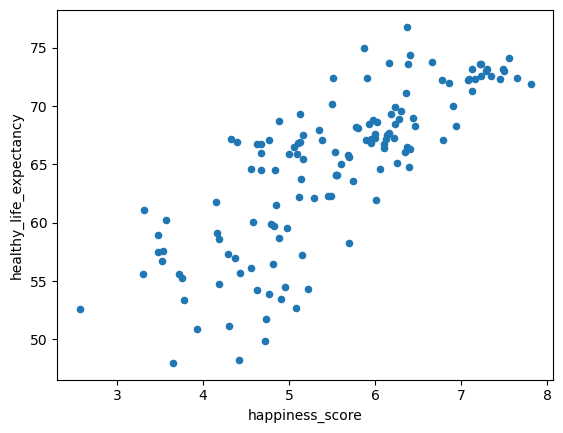

In [18]:
# Write your code here
df.plot.scatter(x='happiness_score',y='healthy_life_expectancy')
plt.show()

Feel free to continue the exploration of the dataset! We'll release the solutions next week.

----
Enjoy EPFL and be happy, next year Switzerland must be #1.